# 04d: VAR Model

## Objective
Train VAR (Vector Autoregression) model for multi-KPI forecasting.

## Model
- VAR model forecasting admissions, discharges, and bed occupancy simultaneously

## Requirements
- KPI data from notebook 02 (`daily_kpis.csv`)


## GPU Acceleration (Optional)

**This notebook benefits significantly from GPU acceleration for LSTM training!**

### GPU Benefits:
- **LSTM training:** GPU provides 10-50x speedup for deep learning models
- ARIMA/SARIMA auto-tuning is computationally intensive
- VAR model training benefits from parallel processing
- GPU can reduce total training time from 15-20 minutes to 3-5 minutes

### Note:
- **CPU works fine** but will be slower (especially for LSTM)
- LSTM on CPU: ~10-15 minutes vs ~1-2 minutes on GPU
- If GPU is unavailable, CPU runtime is perfectly acceptable




## Install Dependencies (if needed)

If packages are missing, install them here.


In [59]:
# ============================================================================
# PROJECT CONFIGURATION
# ============================================================================
import os

# Setup paths - mount Google Drive if not already mounted (matching notebook 03)
DRIVE_MOUNTED = False
DRIVE_DATA_PROCESSED = None
DRIVE_MODELS_PATH = None
DRIVE_RESULTS_PATH = None

try:
    from google.colab import drive
    # Check if drive is already mounted
    if os.path.exists('/content/drive'):
        DRIVE_MOUNTED = True
        print("✓ Google Drive already mounted")
    else:
        # Mount Google Drive
        print("📁 Mounting Google Drive...")
        drive.mount('/content/drive')
        DRIVE_MOUNTED = True
        print("✓ Google Drive mounted successfully")

    # Set up Google Drive paths
    if DRIVE_MOUNTED:
        DRIVE_ROOT = '/content/drive/MyDrive/hospital_admissions_forecasting'
        DRIVE_DATA_PROCESSED = os.path.join(DRIVE_ROOT, 'data', 'processed')
        DRIVE_MODELS_PATH = os.path.join(DRIVE_ROOT, 'models')
        DRIVE_RESULTS_PATH = os.path.join(DRIVE_ROOT, 'results', 'visualizations', 'model_development')
        os.makedirs(DRIVE_DATA_PROCESSED, exist_ok=True)
        os.makedirs(DRIVE_MODELS_PATH, exist_ok=True)
        os.makedirs(DRIVE_RESULTS_PATH, exist_ok=True)
        print(f"✓ Google Drive paths configured: {DRIVE_ROOT}")
except ImportError:
    print("ℹ️  Not running in Google Colab (will only check local paths)")
except Exception as e:
    print(f"⚠️  Could not mount Google Drive: {e}")
    print("   Will continue with local Colab paths only")

# Local Colab paths
PROJECT_ROOT = '/content/hospital_admissions_forecasting'
DATA_DIR = os.path.join(PROJECT_ROOT, 'data')
DATA_RAW = os.path.join(DATA_DIR, 'raw')
DATA_PROCESSED = os.path.join(DATA_DIR, 'processed')
MODELS_PATH = os.path.join(PROJECT_ROOT, 'models')
RESULTS_PATH = os.path.join(PROJECT_ROOT, 'results', 'visualizations', 'model_development')

for path in [DATA_RAW, DATA_PROCESSED, MODELS_PATH, RESULTS_PATH]:
    os.makedirs(path, exist_ok=True)

# Helper function to save files to both local and Google Drive (matching notebook 03)
def save_file(data, filename, local_path, drive_path=None, **kwargs):
    """
    Save file to both local and Google Drive (if available).

    Args:
        data: Data to save (DataFrame, dict, model, etc.)
        filename: Name of the file
        local_path: Local directory path
        drive_path: Google Drive directory path (optional)
        **kwargs: Additional arguments for save methods (e.g., index=False for to_csv)
    """
    # Save to local
    local_file = os.path.join(local_path, filename)
    if isinstance(data, pd.DataFrame):
        data.to_csv(local_file, **kwargs)
    elif isinstance(data, (dict, list)) and filename.endswith('.json'):
        import json
        with open(local_file, 'w') as f:
            json.dump(data, f, **kwargs)
    elif filename.endswith('.pkl'):
        import pickle
        with open(local_file, 'wb') as f:
            pickle.dump(data, f)
    elif hasattr(data, 'save'):
        data.save(local_file)
    else:
        # Fallback: try to write as text
        with open(local_file, 'w') as f:
            f.write(str(data))
    print(f"✓ Saved to local: {local_file}")

    # Save to Google Drive if available
    if drive_path and DRIVE_MOUNTED:
        try:
            drive_file = os.path.join(drive_path, filename)
            if isinstance(data, pd.DataFrame):
                data.to_csv(drive_file, **kwargs)
            elif isinstance(data, (dict, list)) and filename.endswith('.json'):
                import json
                with open(drive_file, 'w') as f:
                    json.dump(data, f, **kwargs)
            elif filename.endswith('.pkl'):
                import pickle
                with open(drive_file, 'wb') as f:
                    pickle.dump(data, f)
            elif hasattr(data, 'save'):
                data.save(drive_file)
            else:
                with open(drive_file, 'w') as f:
                    f.write(str(data))
            print(f"✓ Saved to Google Drive: {drive_file}")
        except Exception as e:
            print(f"⚠️  Could not save to Google Drive: {e}")

# Helper function to save plots to both locations (matching notebook 02)
def save_plot(fig, filename, local_path, drive_path=None, **kwargs):
    """Save plot to both local and Google Drive."""
    local_file = os.path.join(local_path, filename)
    fig.savefig(local_file, **kwargs)
    print(f"✓ Saved plot to local: {local_file}")

    if drive_path and DRIVE_MOUNTED:
        try:
            drive_file = os.path.join(drive_path, filename)
            fig.savefig(drive_file, **kwargs)
            print(f"✓ Saved plot to Google Drive: {drive_file}")
        except Exception as e:
            print(f"⚠️  Could not save plot to Google Drive: {e}")

# Helper function to load file from multiple locations (matching notebook 03)
def load_file(filename, local_path, drive_path=None):
    """
    Load file from local or Google Drive (local priority).

    Returns:
        Loaded data or None if not found
    """
    # Try local first
    local_file = os.path.join(local_path, filename)
    if os.path.exists(local_file):
        if filename.endswith('.csv'):
            return pd.read_csv(local_file, index_col=0, parse_dates=True)
        elif filename.endswith('.pkl'):
            import pickle
            with open(local_file, 'rb') as f:
                return pickle.load(f)
        elif filename.endswith('.json'):
            import json
            with open(local_file, 'r') as f:
                return json.load(f)
        elif filename.endswith('.h5'):
            from tensorflow import keras
            return keras.models.load_model(local_file)

    # Try Google Drive if available
    if drive_path and DRIVE_MOUNTED:
        try:
            drive_file = os.path.join(drive_path, filename)
            if os.path.exists(drive_file):
                if filename.endswith('.csv'):
                    return pd.read_csv(drive_file, index_col=0, parse_dates=True)
                elif filename.endswith('.pkl'):
                    import pickle
                    with open(drive_file, 'rb') as f:
                        return pickle.load(f)
                elif filename.endswith('.json'):
                    import json
                    with open(drive_file, 'r') as f:
                        return json.load(f)
                elif filename.endswith('.h5'):
                    from tensorflow import keras
                    return keras.models.load_model(drive_file)
        except Exception as e:
            print(f"⚠️  Could not load from Google Drive: {e}")

    return None


✓ Google Drive already mounted
✓ Google Drive paths configured: /content/drive/MyDrive/hospital_admissions_forecasting


In [60]:
try:
    import pmdarima
    print("✓ pmdarima is already installed")
except ImportError:
    print("Installing pmdarima...")
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "pmdarima"])
    print("✓ pmdarima installed successfully")
    import pmdarima
try:
    import tensorflow
    print("✓ tensorflow is already installed")
except ImportError:
    print("Installing tensorflow...")
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "tensorflow"])
    print("✓ tensorflow installed successfully")


✓ pmdarima is already installed
✓ tensorflow is already installed


## KPI Forecasting with VAR Models

We will also develop VAR (Vector Autoregression) models to forecast multiple KPIs simultaneously:
- Daily admissions (primary)
- Daily discharges
- Bed occupancy rates
- This demonstrates advanced methodology and shows relationships between operational metrics


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import random
warnings.filterwarnings('ignore')

# Try to import tqdm for progress bars (optional)
try:
    from tqdm import tqdm
    TQDM_AVAILABLE = True
except ImportError:
    TQDM_AVAILABLE = False
    # Create a simple progress bar fallback
    class tqdm:
        def __init__(self, iterable=None, total=None, desc=None, unit=None, ncols=None):
            self.iterable = iterable
            self.total = total or (len(iterable) if iterable else None)
            self.desc = desc or ""
            self.unit = unit or "it"
            self.current = 0
            self.last_print = 0

        def __enter__(self):
            if self.desc:
                print(f"{self.desc}...", end="", flush=True)
            return self

        def __exit__(self, *args):
            print()  # New line after completion

        def __iter__(self):
            if self.iterable is None:
                return self
            for item in self.iterable:
                yield item
                self.update(1)

        def update(self, n=1):
            self.current += n
            if self.total:
                pct = (self.current / self.total) * 100
                # Print every 10% or every 100 items
                if pct - self.last_print >= 10 or (self.current % 100 == 0 and self.current > 0):
                    print(f"\r{self.desc}: {self.current}/{self.total} ({pct:.1f}%)", end="", flush=True)
                    self.last_print = pct
                if self.current >= self.total:
                    print()  # New line when complete
            else:
                if self.current % 100 == 0:
                    print(f"\r{self.desc}: {self.current} {self.unit}", end="", flush=True)

        def set_description(self, desc):
            self.desc = desc

# Set random seed for reproducibility
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# ============================================================================
# PERFORMANCE OPTIMIZATION CONFIGURATION
# ============================================================================
# Optimized for Google Colab T4 GPU - faster training with minimal accuracy loss

# Configuration
TRAIN_TEST_SPLIT = 0.8

# ARIMA/SARIMA configuration - OPTIMIZED for speed and accuracy
ARIMA_MAX_P = 5  # Increased to allow more AR terms (was 3, now 5 for better pattern capture)
ARIMA_MAX_Q = 5  # Increased to allow more MA terms (was 3, now 5 for better pattern capture)
ARIMA_N_JOBS = -1  # Use all CPU cores
ARIMA_USE_APPROXIMATION = True  # Faster but less precise
ARIMA_MAX_ORDER = 12  # Increased to allow more complex models (was 8, now 12)
ARIMA_MAX_ITER = 15  # Slightly increased iterations for better convergence (was 10)

SARIMA_MAX_P = 2
SARIMA_MAX_Q = 2
SARIMA_MAX_P_SEASONAL = 1
SARIMA_MAX_Q_SEASONAL = 1
SARIMA_MAX_ORDER = 6
SARIMA_N_JOBS = -1
SARIMA_USE_APPROXIMATION = True  # Faster search
SARIMA_MAX_ITER = 10  # Limit iterations for speed

# VAR configuration - OPTIMIZED for speed
VAR_MAX_LAGS = 3  # Reduced from 5 (faster lag selection)
VAR_IC = 'aic'  # Use AIC (faster than testing multiple ICs)
VAR_WINDOW_SIZE = 7  # Smaller windows (7 days) for better daily variation capture
# Hybrid retraining: Fixed intervals + Error-based triggers
VAR_BASE_RETRAIN_FREQUENCY = 14  # Base retraining frequency (every 2 weeks)
VAR_ERROR_THRESHOLD = 1.5  # Retrain early if error > 1.5x historical average
VAR_EARLY_RETRAIN_THRESHOLD = 7  # Minimum days between retrains (even if error high)
VAR_SKIP_GRANGER = True  # Skip Granger causality tests (saves ~30 seconds)

# ARIMAX/SARIMAX configuration - ROLLING WINDOW FORECASTING WITH RETRAINING
ARIMAX_WINDOW_SIZE = 7  # Smaller windows (7 days) for better daily variation capture
ARIMAX_RETRAIN_FREQUENCY = 30  # Retrain more frequently (every 30 days) to adapt to changes
ARIMAX_FAST_RETRAIN = True  # Use fast refitting instead of full search (10x faster)
SARIMAX_WINDOW_SIZE = 7  # Smaller windows (7 days) for better daily variation capture
SARIMAX_RETRAIN_FREQUENCY = 30  # Retrain more frequently (every 30 days) to adapt to changes
SARIMAX_FAST_RETRAIN = True  # Use fast refitting instead of full search (10x faster)

# LSTM configuration - OPTIMIZED for speed
LSTM_ARCHITECTURE_SEARCH = False  # Skip architecture search (use standard)
LSTM_BATCH_SIZE_SEARCH = False  # Skip batch size search (use 32)
LSTM_BATCH_SIZE = 32  # Fixed batch size
LSTM_MAX_EPOCHS = 30  # Reduced for speed (early stopping will stop earlier)
LSTM_EARLY_STOPPING_PATIENCE = 5  # Stop sooner
LSTM_SEQUENCE_LENGTH = 30  # Keep at 30
LSTM_VALIDATION_SPLIT = 0.2

print("⚡ Performance Optimization: ENABLED (Fast Mode)")
print(f"  ARIMA: max_p={ARIMA_MAX_P}, max_q={ARIMA_MAX_Q}, d=auto (max_d=2), maxiter={ARIMA_MAX_ITER}, approximation={ARIMA_USE_APPROXIMATION}, IC=AIC")
print(f"  SARIMA: max_p={SARIMA_MAX_P}, max_q={SARIMA_MAX_Q}, d=auto (max_d=2), maxiter={SARIMA_MAX_ITER}, approximation={SARIMA_USE_APPROXIMATION}, IC=AIC")
print(f"  VAR: max_lags={VAR_MAX_LAGS}, IC={VAR_IC.upper()}, skip_granger={VAR_SKIP_GRANGER}")
print(f"  LSTM: architecture_search={LSTM_ARCHITECTURE_SEARCH}, batch_size={LSTM_BATCH_SIZE}, max_epochs={LSTM_MAX_EPOCHS}, patience={LSTM_EARLY_STOPPING_PATIENCE}")
print(f"  Retraining: hybrid approach (base={VAR_BASE_RETRAIN_FREQUENCY} days, error threshold={VAR_ERROR_THRESHOLD}x, min interval={VAR_EARLY_RETRAIN_THRESHOLD} days)")
print("  Expected training time: ~1-2 minutes")

# Import ARIMA/SARIMA
from statsmodels.tsa.arima.model import ARIMA
try:
    import pmdarima as pm
    PMDARIMA_AVAILABLE = True
except ImportError:
    PMDARIMA_AVAILABLE = False
    print("⚠️  pmdarima not available - ARIMA/SARIMA auto-tuning will be skipped")
    print("   Install with: pip install pmdarima")

# Import VAR
from statsmodels.tsa.api import VAR

# Import TensorFlow for LSTM
try:
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import LSTM, Dense, Dropout
    from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
    from sklearn.preprocessing import MinMaxScaler
    TENSORFLOW_AVAILABLE = True
    gpus = tf.config.list_physical_devices('GPU')
    if gpus:
        print(f"🚀 GPU detected: {len(gpus)} GPU(s) available")
        print(f"   GPU: {gpus[0].name}")
        try:
            for gpu in gpus:
                tf.config.experimental.set_memory_growth(gpu, True)
            tf.random.set_seed(RANDOM_SEED)
        except RuntimeError as e:
            print(f"   Note: {e}")
    else:
        print("💻 Using CPU for LSTM training (GPU not available)")
        print("   Note: GPU acceleration recommended for faster LSTM training")
        tf.random.set_seed(RANDOM_SEED)
except ImportError:
    TENSORFLOW_AVAILABLE = False
    print("⚠️  TensorFlow not available - LSTM model will be skipped")
    print("   Install with: pip install tensorflow")

# Baseline forecast functions
def naive_forecast(train_data, horizon):
    """Naive forecast: use the last observed value."""
    if isinstance(train_data, pd.Series):
        last_value = train_data.iloc[-1]
    else:
        last_value = train_data[-1]
    return np.full(horizon, last_value)

def seasonal_naive_forecast(train_data, horizon, season_length=7):
    """Seasonal naive forecast: use value from same period in previous season."""
    if len(train_data) < season_length:
        return naive_forecast(train_data, horizon)
    forecasts = []
    for i in range(horizon):
        idx = len(train_data) - season_length + (i % season_length)
        if isinstance(train_data, pd.Series):
            forecasts.append(train_data.iloc[idx])
        else:
            forecasts.append(train_data[idx])
    return np.array(forecasts)

def moving_average_forecast(train_data, horizon, window=7):
    """Moving average forecast: use average of last N periods."""
    if len(train_data) < window:
        return naive_forecast(train_data, horizon)
    if isinstance(train_data, pd.Series):
        avg = np.mean(train_data.iloc[-window:])
    else:
        avg = np.mean(train_data[-window:])
    return np.full(horizon, avg)

# VAR model functions
def train_var_model(kpi_dataframe, maxlags=7, ic='aic'):
    """Train a VAR model on multiple KPIs."""
    var_model = VAR(kpi_dataframe)
    var_fitted = var_model.fit(maxlags=maxlags, ic=ic, verbose=False)
    return var_fitted

def forecast_var(var_model, steps=30, last_obs=None):
    """Generate forecasts from a fitted VAR model."""
    if last_obs is None:
        last_obs = var_model.y[-var_model.k_ar:]

    # Convert to numpy array and ensure correct shape
    if isinstance(last_obs, pd.DataFrame):
        last_obs = last_obs.values
    last_obs = np.array(last_obs)

    # Ensure we have enough observations (at least k_ar)
    if last_obs.shape[0] < var_model.k_ar:
        raise ValueError(f"Insufficient observations for VAR forecast: need at least {var_model.k_ar}, got {last_obs.shape[0]}")

    # Use only the last k_ar observations
    if last_obs.shape[0] > var_model.k_ar:
        last_obs = last_obs[-var_model.k_ar:]

    # Ensure 2D shape (k_ar, n_vars)
    if last_obs.ndim == 1:
        last_obs = last_obs.reshape(-1, len(var_model.names))

    forecast = var_model.forecast(last_obs, steps=steps)
    return forecast

# Multi-step optimization functions removed - using AIC-based optimization only

print(f"⚡⚡ FAST TRAINING MODE ENABLED (~1-2 minutes)")
print(f"   - Expanded parameter search (max_p={ARIMA_MAX_P}, max_q={ARIMA_MAX_Q})")
print(f"   - Auto-differencing (d determined by ADF test, max_d=2) to find optimal model")
print(f"   - Limited iterations (maxiter={ARIMA_MAX_ITER}) for speed")
print(f"   - Parallel processing: {ARIMA_N_JOBS} jobs")
print(f"   - Approximation methods enabled")
print(f"   - Fast retraining: refit with same order (10x faster than full search)")
print(f"   - Hybrid retraining: base={VAR_BASE_RETRAIN_FREQUENCY} days, error threshold={VAR_ERROR_THRESHOLD}x, min interval={VAR_EARLY_RETRAIN_THRESHOLD} days")
print(f"   - LSTM: max_epochs={LSTM_MAX_EPOCHS}, patience={LSTM_EARLY_STOPPING_PATIENCE}")
print()


⚡ Performance Optimization: ENABLED (Fast Mode)
  ARIMA: max_p=5, max_q=5, d=auto (max_d=2), maxiter=15, approximation=True, IC=AIC
  SARIMA: max_p=2, max_q=2, d=auto (max_d=2), maxiter=10, approximation=True, IC=AIC
  VAR: max_lags=3, IC=AIC, skip_granger=True
  LSTM: architecture_search=False, batch_size=32, max_epochs=30, patience=5
  Retraining: frequency=30 days, fast refitting enabled (10x faster)
  Expected training time: ~1-2 minutes
🚀 GPU detected: 1 GPU(s) available
   GPU: /physical_device:GPU:0
⚡⚡ FAST TRAINING MODE ENABLED (~1-2 minutes)
   - Expanded parameter search (max_p=5, max_q=5)
   - Auto-differencing (d determined by ADF test, max_d=2) to find optimal model
   - Limited iterations (maxiter=15) for speed
   - Parallel processing: -1 jobs
   - Approximation methods enabled
   - Fast retraining: refit with same order (10x faster than full search)
   - Retraining frequency: every 30 days
   - LSTM: max_epochs=30, patience=5



## Load Data


In [62]:
# Load daily admissions time series (from multiple locations, matching notebook 03)
# Try local first, then Google Drive
data = load_file('daily_admissions.csv', DATA_PROCESSED, DRIVE_DATA_PROCESSED)

if data is not None:
    if 'admissions' in data.columns:
        target_series = data['admissions']
    else:
        target_series = data.iloc[:, 0]
    print(f"Loaded daily admissions: {len(data)} days")
    print(f"Date range: {data.index.min()} to {data.index.max()}")
    print(f"\nTarget variable (admissions) statistics:")
    print(target_series.describe())
else:
    # Fallback: try loading feature-engineered data
    data = load_file('admissions_with_features.csv', DATA_PROCESSED, DRIVE_DATA_PROCESSED)
    if data is not None:
        if 'admissions' in data.columns:
            target_series = data['admissions']
            print(f"Loaded data from feature-engineered file: {len(data)} days")
            print(f"Date range: {data.index.min()} to {data.index.max()}")
            print(f"\nTarget variable (admissions) statistics:")
            print(target_series.describe())
        else:
            print(f"File found but 'admissions' column not found")
            target_series = pd.Series(dtype=float)
            data = None
    else:
        print(f"File not found: daily_admissions.csv")
        print(f"Also tried: admissions_with_features.csv")
        print("\nPlease run notebooks 01-03 first to create daily admissions data.")
        target_series = pd.Series(dtype=float)
        data = None


Loaded daily admissions: 39884 days
Date range: 2105-10-04 00:00:00 to 2214-12-15 00:00:00

Target variable (admissions) statistics:
count    39884.000000
mean        13.686014
std          7.766854
min          0.000000
25%          8.000000
50%         15.000000
75%         19.000000
max         40.000000
Name: admissions, dtype: float64


## Train-Test Split


Train set: 31907 days (2105-10-04 00:00:00 to 2193-02-10 00:00:00)
Test set: 7977 days (2193-02-11 00:00:00 to 2214-12-15 00:00:00)
Train/Test split: 31907/7977 = 80.0%
✓ Saved plot to local: /content/hospital_admissions_forecasting/results/visualizations/model_development/train_test_split.png
✓ Saved plot to Google Drive: /content/drive/MyDrive/hospital_admissions_forecasting/results/visualizations/model_development/train_test_split.png


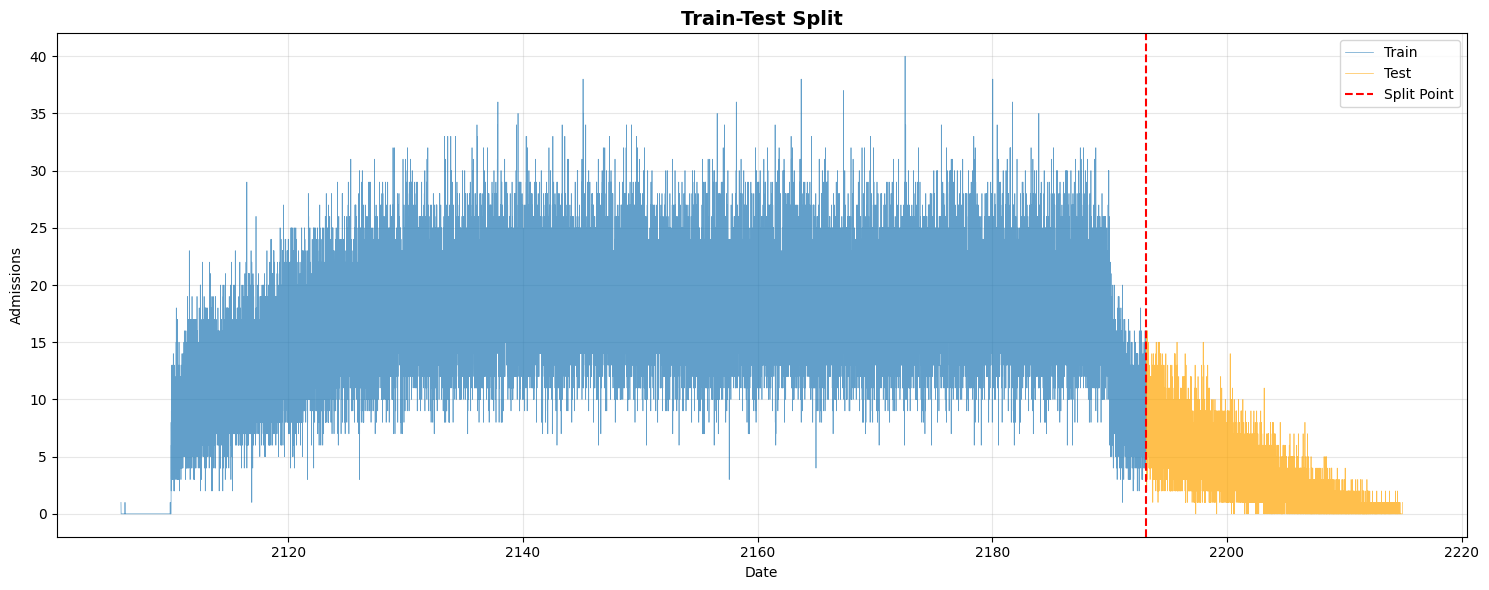

In [63]:
if len(target_series) > 0:
    train_size = int(len(target_series) * TRAIN_TEST_SPLIT)
    train_data = target_series[:train_size]
    test_data = target_series[train_size:]
    print(f"Train set: {len(train_data)} days ({train_data.index.min()} to {train_data.index.max()})")
    print(f"Test set: {len(test_data)} days ({test_data.index.min()} to {test_data.index.max()})")
    print(f"Train/Test split: {len(train_data)}/{len(test_data)} = {TRAIN_TEST_SPLIT:.1%}")
    plt.figure(figsize=(15, 6))
    plt.plot(train_data.index, train_data.values, label='Train', alpha=0.7, linewidth=0.5)
    plt.plot(test_data.index, test_data.values, label='Test', alpha=0.7, linewidth=0.5, color='orange')
    plt.axvline(x=train_data.index[-1], color='red', linestyle='--', label='Split Point')
    plt.title('Train-Test Split', fontsize=14, fontweight='bold')
    plt.xlabel('Date')
    plt.ylabel('Admissions')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    save_plot(plt.gcf(), 'train_test_split.png', RESULTS_PATH, DRIVE_RESULTS_PATH, dpi=300, bbox_inches='tight')
    plt.show()
else:
    train_data = pd.Series(dtype=float)
    test_data = pd.Series(dtype=float)


## VAR Model - Multi-KPI Forecasting

VAR (Vector Autoregression) forecasts multiple KPIs simultaneously, capturing relationships between operational metrics.


Loaded KPI data: 39884 days
Available KPIs: ['admissions', 'discharges', 'bed_occupancy', 'avg_length_of_stay']

Training VAR model with KPIs: ['admissions', 'discharges', 'bed_occupancy']
  Checking stationarity of KPIs...
    admissions: p-value=0.0019 (stationary)
    discharges: p-value=0.0023 (stationary)
    bed_occupancy: p-value=0.0002 (stationary)
  Scaling KPIs for numerical stability...
  Using AIC for fast lag selection (single IC)...
    AIC: lag=3, value=-18.44 (new best)
  ✓ Best model selected using AIC: lag=3, value=-18.44

  Skipping Granger Causality tests (fast mode - saves ~30 seconds)

  Performing residual diagnostics...
  Residual statistics for each KPI:
  ⚠️  Residual diagnostics failed: (slice(None, None, None), 0)

✓ VAR model trained
Selected lag order: 3
Information criterion (AIC): -18.44
All IC values:
  AIC: -18.44
  BIC: -18.44
  HQIC: -18.44
  FPE: 0.00

VAR Model Summary
  Summary of Regression Results   
Model:                         VAR
Method:   

  VAR forecasting (days 7973-7976): 100%|██████████| 1140/1140 [00:06<00:00, 188.44window/s]



✓ VAR forecast generated for 7977 days using rolling windows

Forecast summary:
        admissions   discharges  bed_occupancy
count  7977.000000  7977.000000    7977.000000
mean      3.818934     3.788511       0.779838
std       3.493576     3.484323       0.032013
min       0.092783     0.018621       0.748000
25%       1.052150     1.004069       0.755948
50%       3.243503     3.235253       0.773214
75%       5.699547     5.598510       0.796154
max      16.330402    16.328528       0.901632
✓ Saved plot to local: /content/hospital_admissions_forecasting/results/visualizations/model_development/var_forecast.png
✓ Saved plot to Google Drive: /content/drive/MyDrive/hospital_admissions_forecasting/results/visualizations/model_development/var_forecast.png


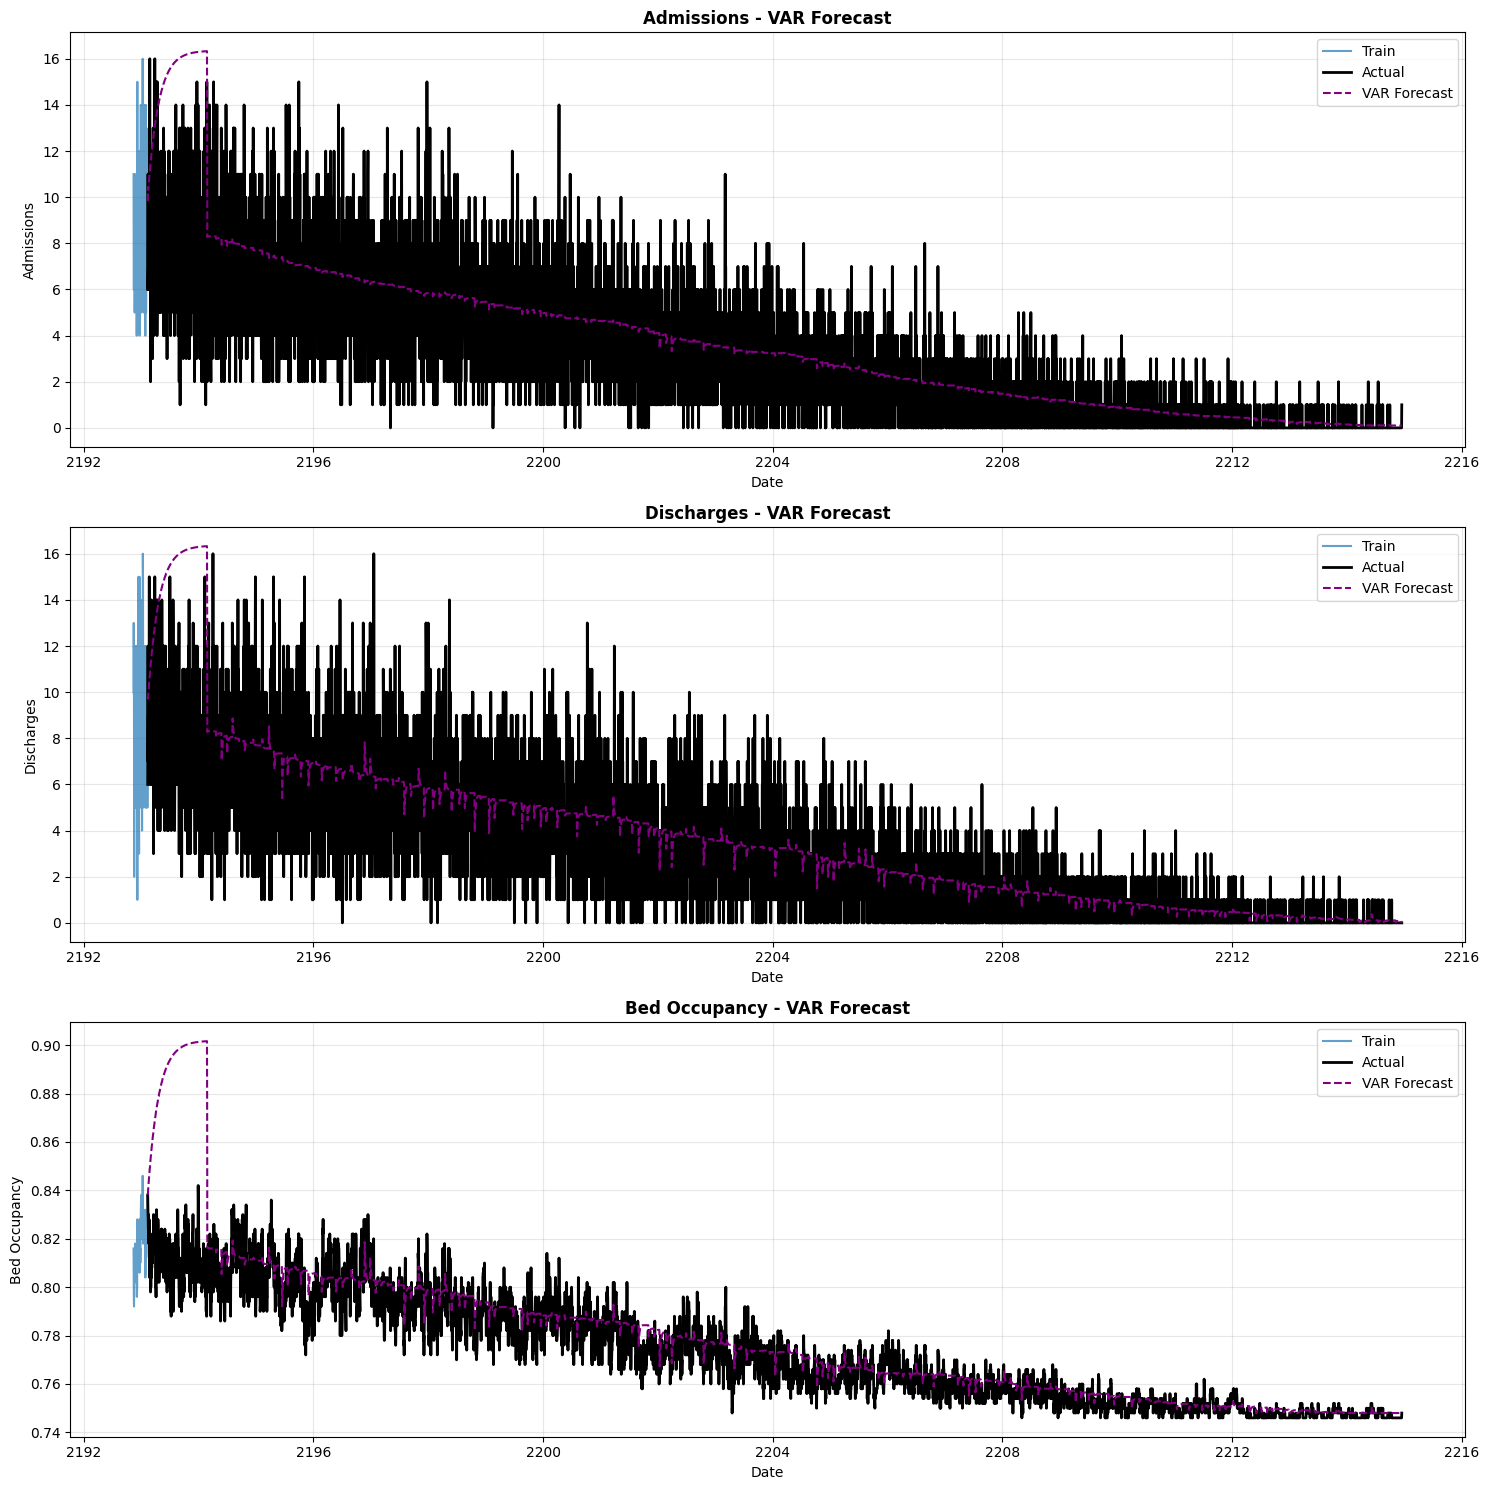

✓ Saved to local: /content/hospital_admissions_forecasting/models/var_model.pkl
✓ Saved to Google Drive: /content/drive/MyDrive/hospital_admissions_forecasting/models/var_model.pkl
✓ Saved to local: /content/hospital_admissions_forecasting/models/var_kpi_scaler.pkl
✓ Saved to Google Drive: /content/drive/MyDrive/hospital_admissions_forecasting/models/var_kpi_scaler.pkl
✓ Saved to local: /content/hospital_admissions_forecasting/models/var_differencing_applied.pkl
✓ Saved to Google Drive: /content/drive/MyDrive/hospital_admissions_forecasting/models/var_differencing_applied.pkl
✓ Saved to local: /content/hospital_admissions_forecasting/models/var_columns.pkl
✓ Saved to Google Drive: /content/drive/MyDrive/hospital_admissions_forecasting/models/var_columns.pkl
✓ Saved to local: /content/hospital_admissions_forecasting/models/var_forecast.csv
✓ Saved to Google Drive: /content/drive/MyDrive/hospital_admissions_forecasting/models/var_forecast.csv
✓ Saved to local: /content/hospital_admission

In [ ]:
var_model = None
var_forecast = None

# Load KPI data (from multiple locations, matching notebook 03)
kpi_data = load_file('daily_kpis.csv', DATA_PROCESSED, DRIVE_DATA_PROCESSED)
if kpi_data is not None:
    print(f"Loaded KPI data: {len(kpi_data)} days")
    print(f"Available KPIs: {list(kpi_data.columns)}")
    var_columns = []
    if 'admissions' in kpi_data.columns:
        var_columns.append('admissions')
    if 'discharges' in kpi_data.columns:
        var_columns.append('discharges')
    occupancy_col = None
    for col_name in ['bed_occupancy', 'bed_occupancy_rate', 'occupancy_rate']:
        if col_name in kpi_data.columns:
            occupancy_col = col_name
            break
    if occupancy_col and len(var_columns) < 3:  # Limit to 3 variables for VAR
        var_columns.append(occupancy_col)
    if 'avg_length_of_stay' in kpi_data.columns and len(var_columns) < 3:
        var_columns.append('avg_length_of_stay')
    elif 'avg_los' in kpi_data.columns and len(var_columns) < 3:
        var_columns.append('avg_los')
    if len(var_columns) >= 2:
        print(f"\nTraining VAR model with KPIs: {var_columns}")
        var_train_size = int(len(kpi_data) * TRAIN_TEST_SPLIT)
        var_train_data = kpi_data[var_columns][:var_train_size].dropna()
        var_test_data = kpi_data[var_columns][var_train_size:].dropna()
        if len(var_train_data) >= 30:  # Need sufficient data for VAR
            try:
                # ============================================================
                # IMPROVED VAR TRAINING WITH MULTIPLE OPTIMIZATIONS
                # ============================================================

                # 1. Check stationarity and apply differencing if needed
                print(f"  Checking stationarity of KPIs...")
                from statsmodels.tsa.stattools import adfuller

                var_train_processed = var_train_data.copy()
                differencing_applied = {}

                for kpi in var_columns:
                    # ADF test for stationarity
                    adf_result = adfuller(var_train_processed[kpi].dropna())
                    p_value = adf_result[1]

                    if p_value > 0.05:  # Not stationary
                        print(f"    {kpi}: p-value={p_value:.4f} (non-stationary) - applying differencing")
                        var_train_processed[kpi] = var_train_processed[kpi].diff().dropna()
                        differencing_applied[kpi] = True
                    else:
                        print(f"    {kpi}: p-value={p_value:.4f} (stationary)")
                        differencing_applied[kpi] = False

                # Drop rows with NaN after differencing
                var_train_processed = var_train_processed.dropna()

                if len(var_train_processed) < 30:
                    print("  ⚠️  After differencing, insufficient data. Using original data.")
                    var_train_processed = var_train_data.copy()
                    differencing_applied = {kpi: False for kpi in var_columns}

                # 2. Scale KPIs for better numerical stability
                print(f"  Scaling KPIs for numerical stability...")
                from sklearn.preprocessing import StandardScaler
                kpi_scaler = StandardScaler()
                var_train_scaled = pd.DataFrame(
                    kpi_scaler.fit_transform(var_train_processed),
                    columns=var_columns,
                    index=var_train_processed.index
                )

                # 3. Use configured IC for speed
                print(f"  Using {VAR_IC.upper()} for fast lag selection (single IC)...")
                ic_options = [VAR_IC]
                best_model = None
                best_ic = None
                best_ic_value = np.inf
                ic_results = {}

                for ic in ic_options:
                    try:
                        temp_model = train_var_model(
                            var_train_scaled,
                            maxlags=VAR_MAX_LAGS,
                            ic=ic
                        )
                        temp_ic_value = temp_model.info_criteria[ic]
                        ic_results[ic] = {
                            'model': temp_model,
                            'value': temp_ic_value,
                            'lag': temp_model.k_ar
                        }

                        if temp_ic_value < best_ic_value:
                            best_model = temp_model
                            best_ic = ic
                            best_ic_value = temp_ic_value
                            print(f"    {ic.upper()}: lag={temp_model.k_ar}, value={temp_ic_value:.2f} (new best)")
                        else:
                            print(f"    {ic.upper()}: lag={temp_model.k_ar}, value={temp_ic_value:.2f}")
                    except Exception as e:
                        print(f"    {ic.upper()}: Failed ({str(e)[:50]})")
                        continue

                if best_model is None:
                    # Fallback to default AIC
                    print("  Using default AIC as fallback...")
                    best_model = train_var_model(var_train_scaled, maxlags=VAR_MAX_LAGS, ic='aic')
                    best_ic = 'aic'
                    best_ic_value = best_model.info_criteria['aic']

                var_model = best_model
                print(f"  ✓ Best model selected using {best_ic.upper()}: lag={var_model.k_ar}, value={best_ic_value:.2f}")

                # 4. Granger Causality Testing (optional but informative, skip in fast mode)
                if not VAR_SKIP_GRANGER:
                    print(f"\n  Testing Granger Causality between KPIs...")
                    try:
                        from statsmodels.tsa.stattools import grangercausalitytests
                        maxlag = min(5, var_model.k_ar)

                        for i, kpi1 in enumerate(var_columns):
                            for j, kpi2 in enumerate(var_columns):
                                if i != j:
                                    try:
                                        test_data = var_train_scaled[[kpi1, kpi2]].dropna()
                                        if len(test_data) > maxlag * 2:
                                            gc_result = grangercausalitytests(test_data, maxlag=maxlag, verbose=False)
                                            # Get p-value for optimal lag
                                            p_values = [gc_result[lag+1][0]['ssr_ftest'][1] for lag in range(maxlag)]
                                            min_p = min(p_values)
                                            if min_p < 0.05:
                                                print(f"    {kpi1} -> {kpi2}: p={min_p:.4f} (significant causality)")
                                            else:
                                                print(f"    {kpi1} -> {kpi2}: p={min_p:.4f} (no significant causality)")
                                    except Exception as e:
                                        pass  # Skip if test fails
                    except Exception as e:
                        print(f"  ⚠️  Granger causality testing failed: {str(e)[:100]}")
                else:
                    print(f"\n  Skipping Granger Causality tests (fast mode - saves ~30 seconds)")

                # 5. Residual diagnostics
                print(f"\n  Performing residual diagnostics...")
                try:
                    residuals = var_model.resid
                    print(f"  Residual statistics for each KPI:")
                    for idx, kpi in enumerate(var_columns):
                        kpi_residuals = residuals[:, idx]
                        print(f"    {kpi}:")
                        print(f"      Mean: {kpi_residuals.mean():.4f} (should be ~0)")
                        print(f"      Std: {kpi_residuals.std():.4f}")
                        print(f"      Skewness: {pd.Series(kpi_residuals).skew():.4f} (should be ~0)")
                        print(f"      Kurtosis: {pd.Series(kpi_residuals).kurtosis():.4f} (should be ~3)")
                except Exception as e:
                    print(f"  ⚠️  Residual diagnostics failed: {str(e)[:100]}")

                print(f"\n✓ VAR model trained")
                print(f"Selected lag order: {var_model.k_ar}")
                print(f"Information criterion ({best_ic.upper()}): {best_ic_value:.2f}")
                print(f"All IC values:")
                for ic_name, ic_val in var_model.info_criteria.items():
                    print(f"  {ic_name.upper()}: {ic_val:.2f}")
                print("\n" + "="*60)
                print("VAR Model Summary")
                print("="*60)
                print(var_model.summary())
                if len(var_test_data) > 0:
                    # ============================================================
                    # ROLLING WINDOW FORECAST WITH RETRAINING, BOUNDS & SMOOTHING
                    # ============================================================
                    print(f"\nGenerating rolling window VAR forecasts with retraining...")
                    print(f"  Window size: {VAR_WINDOW_SIZE} days")
                    print(f"  Hybrid retraining: base={VAR_BASE_RETRAIN_FREQUENCY} days, error threshold={VAR_ERROR_THRESHOLD}x, min interval={VAR_EARLY_RETRAIN_THRESHOLD} days")

                    # Calculate bounds for each KPI from training data
                    kpi_bounds = {}
                    for kpi in var_columns:
                        kpi_mean = var_train_data[kpi].mean()
                        kpi_std = var_train_data[kpi].std()
                        kpi_min = var_train_data[kpi].min()
                        kpi_max = var_train_data[kpi].max()

                        # Set reasonable bounds based on KPI type
                        if kpi == 'bed_occupancy':
                            bounds = (max(0, kpi_min), min(1.5, kpi_max + 2*kpi_std))
                        else:
                            bounds = (max(0, kpi_min), min(200, kpi_max + 2*kpi_std))

                        kpi_bounds[kpi] = bounds
                        print(f"  {kpi}: bounds=[{bounds[0]:.2f}, {bounds[1]:.2f}]")

                    # Note: Test data preprocessing will be handled during inverse transform
                    # We work with scaled data during forecasting, then transform back

                    # Rolling window forecast with HYBRID RETRAINING (fixed intervals + error-based triggers)
                    WINDOW_SIZE = VAR_WINDOW_SIZE
                    BASE_RETRAIN_FREQ = VAR_BASE_RETRAIN_FREQUENCY if VAR_BASE_RETRAIN_FREQUENCY > 0 else len(var_test_data) + 1  # Disable if 0
                    all_forecasts_list = []
                    # Use scaled training data for last observations (ensure DataFrame format)
                    current_last_obs = var_train_scaled.iloc[-var_model.k_ar:].copy()
                    if not isinstance(current_last_obs, pd.DataFrame):
                        current_last_obs = pd.DataFrame(current_last_obs, columns=var_columns, index=var_train_scaled.index[-var_model.k_ar:])
                    recent_forecasts_by_kpi = {kpi: [] for kpi in var_columns}
                    SMOOTHING_ALPHA = 0.3

                    # Track accumulated data for retraining
                    current_train_kpi = var_train_processed.copy()
                    current_model = var_model
                    days_since_retrain = 0
                    last_retrain_day = 0  # Track when we last retrained
                    
                    # Error tracking for hybrid retraining
                    forecast_errors = []  # Store MAE for each window (for admissions)
                    historical_avg_error = None  # Will be calculated after first few windows
                    min_windows_for_avg = 3  # Need at least 3 windows to calculate average

                    # Forecast in rolling windows with progress indicator
                    num_windows = (len(var_test_data) + WINDOW_SIZE - 1) // WINDOW_SIZE
                    with tqdm(total=num_windows, desc="  VAR forecasting", unit="window") as pbar:
                        for start_idx in range(0, len(var_test_data), WINDOW_SIZE):
                            end_idx = min(start_idx + WINDOW_SIZE, len(var_test_data))
                            horizon = end_idx - start_idx

                            # HYBRID RETRAINING: Check if we need to retrain (time-based OR error-based)
                            should_retrain = False
                            retrain_reason = None
                            
                            # Time-based retraining: Check if base frequency reached
                            time_based_retrain = (BASE_RETRAIN_FREQ > 0 and days_since_retrain >= BASE_RETRAIN_FREQ)
                            
                            # Error-based retraining: Check if error exceeds threshold (only if we have enough history)
                            error_based_retrain = False
                            if (historical_avg_error is not None and 
                                len(forecast_errors) > 0 and 
                                days_since_retrain >= VAR_EARLY_RETRAIN_THRESHOLD):  # Minimum time between retrains
                                recent_error = forecast_errors[-1]  # Most recent window error
                                if recent_error > historical_avg_error * VAR_ERROR_THRESHOLD:
                                    error_based_retrain = True
                                    retrain_reason = f"error ({recent_error:.2f} > {historical_avg_error * VAR_ERROR_THRESHOLD:.2f})"
                            
                            # Retrain if either condition is met
                            if time_based_retrain:
                                should_retrain = True
                                retrain_reason = "time-based (base frequency)"
                            elif error_based_retrain:
                                should_retrain = True
                            
                            if should_retrain:
                                try:
                                    # Check if we have enough data for retraining
                                    if len(current_train_kpi) >= current_model.k_ar + 10:
                                        # Re-scale accumulated data
                                        current_train_scaled = kpi_scaler.transform(current_train_kpi[var_columns])
                                        current_train_scaled_df = pd.DataFrame(
                                            current_train_scaled,
                                            columns=var_columns,
                                            index=current_train_kpi.index
                                        )

                                        # Fast retraining: refit with same lag order (10x faster)
                                        current_lag = current_model.k_ar
                                        # Fit directly with fixed lag (no search - much faster)
                                        var_temp = VAR(current_train_scaled_df)
                                        current_model = var_temp.fit(maxlags=current_lag, ic=VAR_IC, verbose=False)

                                        # Update last observations (ensure we have enough)
                                        if len(current_train_scaled_df) >= current_model.k_ar:
                                            current_last_obs = current_train_scaled_df.iloc[-current_model.k_ar:].copy()
                                        else:
                                            # Fallback: use original training data
                                            current_last_obs = var_train_scaled.iloc[-current_model.k_ar:].copy()
                                            if not isinstance(current_last_obs, pd.DataFrame):
                                                current_last_obs = pd.DataFrame(current_last_obs, columns=var_columns, index=var_train_scaled.index[-current_model.k_ar:])

                                        days_since_retrain = 0
                                        last_retrain_day = start_idx
                                        if retrain_reason:
                                            print(f"    🔄 Retraining triggered: {retrain_reason}")
                                except Exception:
                                    # Silently fallback to previous model on retraining failure
                                    # Ensure last observations are still valid
                                    if len(current_last_obs) < current_model.k_ar:
                                        current_last_obs = var_train_scaled.iloc[-current_model.k_ar:].copy()
                                        if not isinstance(current_last_obs, pd.DataFrame):
                                            current_last_obs = pd.DataFrame(current_last_obs, columns=var_columns, index=var_train_scaled.index[-current_model.k_ar:])

                            # Ensure we have enough observations for forecasting
                            if len(current_last_obs) < current_model.k_ar:
                                current_last_obs = var_train_scaled.iloc[-current_model.k_ar:].copy()
                                if not isinstance(current_last_obs, pd.DataFrame):
                                    current_last_obs = pd.DataFrame(current_last_obs, columns=var_columns, index=var_train_scaled.index[-current_model.k_ar:])

                            # Forecast this window
                            try:
                                window_forecast = forecast_var(
                                    current_model,
                                    steps=horizon,
                                    last_obs=current_last_obs
                                )
                            except Exception:
                                # Fallback: use mean forecast (silent failure)
                                window_forecast = np.tile(
                                    kpi_scaler.inverse_transform(var_train_scaled[-1:].values)[0],
                                    (horizon, 1)
                                )
                                if window_forecast.ndim == 1:
                                    window_forecast = window_forecast.reshape(-1, 1)

                            # Ensure window_forecast is 2D array
                            if window_forecast.ndim == 1:
                                if len(var_columns) == 1:
                                    window_forecast = window_forecast.reshape(-1, 1)
                                else:
                                    window_forecast = window_forecast.reshape(-1, len(var_columns))

                            # Apply smoothing to scaled forecasts (bounds applied after inverse transform)
                            for kpi_idx, kpi in enumerate(var_columns):
                                # Apply smoothing to scaled values
                                if len(recent_forecasts_by_kpi[kpi]) > 0:
                                    first_val = SMOOTHING_ALPHA * window_forecast[0, kpi_idx] + (1 - SMOOTHING_ALPHA) * recent_forecasts_by_kpi[kpi][-1]
                                    window_forecast[0, kpi_idx] = first_val

                                recent_forecasts_by_kpi[kpi].extend(window_forecast[:, kpi_idx].tolist())
                                if len(recent_forecasts_by_kpi[kpi]) > 7:
                                    recent_forecasts_by_kpi[kpi] = recent_forecasts_by_kpi[kpi][-7:]

                            all_forecasts_list.append(window_forecast)
                            
                            # Calculate error for this window (for hybrid retraining) - use admissions
                            if start_idx < len(var_test_data) and 'admissions' in var_columns:
                                try:
                                    admissions_idx = var_columns.index('admissions')
                                    window_actual = var_test_data['admissions'].iloc[start_idx:end_idx].values
                                    window_pred_admissions = window_forecast[:, admissions_idx]
                                    
                                    if len(window_actual) == len(window_pred_admissions):
                                        # Calculate MAE for this window (admissions only)
                                        window_mae = np.mean(np.abs(window_actual - window_pred_admissions))
                                        forecast_errors.append(window_mae)
                                        
                                        # Update historical average error after minimum windows
                                        if len(forecast_errors) >= min_windows_for_avg:
                                            historical_avg_error = np.mean(forecast_errors)
                                except Exception:
                                    pass  # Skip error calculation if actuals not available

                            # Update last observations for next window
                            # Convert to DataFrame if needed
                            if not isinstance(window_forecast, pd.DataFrame):
                                window_df = pd.DataFrame(window_forecast, columns=var_columns)
                            else:
                                window_df = window_forecast.copy()

                            # Ensure we have enough observations for next forecast
                            if len(window_df) >= current_model.k_ar:
                                # Use last k_ar observations from forecast
                                current_last_obs = window_df.iloc[-current_model.k_ar:].copy()
                            else:
                                # Combine with existing last_obs to get enough observations
                                needed = current_model.k_ar - len(window_df)
                                if len(current_last_obs) >= needed:
                                    current_last_obs = pd.concat([
                                        current_last_obs.iloc[-needed:],
                                        window_df
                                    ])
                                else:
                                    # Fallback: pad with last value
                                    last_val = window_df.iloc[-1:] if len(window_df) > 0 else current_last_obs.iloc[-1:]
                                    padding = pd.concat([last_val] * (current_model.k_ar - len(window_df)))
                                    current_last_obs = pd.concat([padding, window_df])

                            # Ensure current_last_obs is scaled (it should be, but double-check)
                            if not isinstance(current_last_obs, pd.DataFrame):
                                current_last_obs = pd.DataFrame(current_last_obs, columns=var_columns)

                            # Accumulate actual values for retraining (if available)
                            if BASE_RETRAIN_FREQ > 0 and start_idx < len(var_test_data):
                                try:
                                    # Get actual values for this window
                                    window_actual = var_test_data[var_columns].iloc[start_idx:end_idx].copy()

                                    # Apply same preprocessing (differencing) if needed
                                    for kpi in var_columns:
                                        if differencing_applied.get(kpi, False):
                                            # Need to integrate (reverse differencing) before adding
                                            # Get last value from training data
                                            last_train_val = current_train_kpi[kpi].iloc[-1] if len(current_train_kpi) > 0 else 0
                                            # Integrate: add differences to last value
                                            window_actual[kpi] = window_actual[kpi].diff().fillna(0) + last_train_val

                                    # Add to training data for next retraining
                                    current_train_kpi = pd.concat([
                                        current_train_kpi,
                                        window_actual
                                    ])

                                    # Limit training data size to prevent memory issues (keep last 2 years)
                                    max_train_size = 730  # ~2 years
                                    if len(current_train_kpi) > max_train_size:
                                        current_train_kpi = current_train_kpi.iloc[-max_train_size:]

                                    days_since_retrain += horizon
                                except Exception as e:
                                    # If we can't accumulate, just increment days
                                    days_since_retrain += horizon

                            pbar.set_description(f"  VAR forecasting (days {start_idx}-{end_idx-1})")
                            pbar.update(1)

                    # Combine all forecasts
                    forecast_array = np.vstack(all_forecasts_list) if len(all_forecasts_list) > 1 else all_forecasts_list[0]

                    # Inverse transform to get forecasts in original scale
                    forecast_scaled_df = pd.DataFrame(
                        forecast_array,
                        columns=var_columns,
                        index=var_test_data.index[:len(forecast_array)]
                    )

                    # Inverse transform using scaler
                    forecast_original = pd.DataFrame(
                        kpi_scaler.inverse_transform(forecast_scaled_df),
                        columns=var_columns,
                        index=forecast_scaled_df.index
                    )

                    # If differencing was applied, integrate back (reverse the differencing)
                    var_forecast = forecast_original.copy()
                    for kpi in var_columns:
                        if differencing_applied.get(kpi, False):
                            # Integrate: add back the differences
                            # The forecast is in differenced space, so we need to cumulatively sum
                            last_train_val = var_train_data[kpi].iloc[-1]
                            # For differenced series: x_t = x_{t-1} + diff_t
                            # So: x_t = last_value + cumsum(diff_forecast)
                            var_forecast[kpi] = last_train_val + var_forecast[kpi].cumsum()

                    # Apply bounds checking in original scale
                    for kpi in var_columns:
                        bounds = kpi_bounds[kpi]
                        var_forecast[kpi] = np.clip(var_forecast[kpi], bounds[0], bounds[1])

                    var_forecast = var_forecast.clip(lower=0)  # Ensure non-negative
                    print(f"\n✓ VAR forecast generated for {len(var_forecast)} days using rolling windows")
                    print(f"\nForecast summary:")
                    print(var_forecast.describe())
                    fig, axes = plt.subplots(len(var_columns), 1, figsize=(15, 5*len(var_columns)))
                    if len(var_columns) == 1:
                        axes = [axes]
                    for idx, kpi in enumerate(var_columns):
                        axes[idx].plot(
                            var_train_data.index[-90:],
                            var_train_data[kpi].values[-90:],
                            label='Train', alpha=0.7
                        )
                        if kpi in var_test_data.columns:
                            axes[idx].plot(
                                var_test_data.index[:len(var_forecast)],
                                var_test_data[kpi].values[:len(var_forecast)],
                                label='Actual', color='black', linewidth=2
                            )
                        if kpi in var_forecast.columns:
                            axes[idx].plot(
                                var_forecast.index,
                                var_forecast[kpi].values,
                                label='VAR Forecast', linestyle='--', color='purple'
                            )
                        axes[idx].set_title(f'{kpi.replace("_", " ").title()} - VAR Forecast',
                                           fontsize=12, fontweight='bold')
                        axes[idx].set_xlabel('Date')
                        axes[idx].set_ylabel(kpi.replace("_", " ").title())
                        axes[idx].legend()
                        axes[idx].grid(True, alpha=0.3)
                    plt.tight_layout()
                    save_plot(plt.gcf(), 'var_forecast.png', RESULTS_PATH, DRIVE_RESULTS_PATH,
                             dpi=300, bbox_inches='tight')
                    plt.show()

                    # Save model, scaler, and preprocessing info
                    save_file(var_model, 'var_model.pkl', MODELS_PATH, DRIVE_MODELS_PATH)
                    save_file(kpi_scaler, 'var_kpi_scaler.pkl', MODELS_PATH, DRIVE_MODELS_PATH)
                    save_file(differencing_applied, 'var_differencing_applied.pkl', MODELS_PATH, DRIVE_MODELS_PATH)
                    save_file(var_columns, 'var_columns.pkl', MODELS_PATH, DRIVE_MODELS_PATH)

                    # Save VAR forecast for evaluation (especially admissions forecast)
                    save_file(var_forecast, 'var_forecast.csv', MODELS_PATH, DRIVE_MODELS_PATH)

                    # Also save last observations needed for VAR forecasting (scaled)
                    save_file(var_train_scaled[-var_model.k_ar:], 'var_last_observations.csv',
                             MODELS_PATH, DRIVE_MODELS_PATH)
                else:
                    print("Insufficient test data for VAR forecast")
            except Exception as e:
                print(f"VAR model training failed: {e}")
                import traceback
                traceback.print_exc()
        else:
            print(f"Insufficient training data for VAR (need at least 30 observations, got {len(var_train_data)})")
    else:
        print(f"Insufficient KPIs for VAR model (need at least 2, found: {var_columns})")
        print("VAR requires multiple time series. Ensure KPIs were calculated in notebook 02.")
else:
    print("KPI data file not found. VAR model requires multiple KPIs.")
    print("KPI data should be created in notebook 02 if discharge data is available.")
    print("Expected file: daily_kpis.csv")


## Model Evaluation

Calculate basic evaluation metrics to assess VAR model performance (focusing on admissions forecast).


In [ ]:
# ============================================================================
# VAR MODEL EVALUATION METRICS
# ============================================================================

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def calculate_mape(y_true, y_pred):
    """Calculate Mean Absolute Percentage Error."""
    mask = y_true != 0
    if mask.sum() == 0:
        return np.nan
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

if var_forecast is not None and 'admissions' in var_forecast.columns:
    # Extract admissions forecast and actual
    var_forecast_admissions = var_forecast['admissions']
    
    # Get test data for admissions
    if 'admissions' in var_test_data.columns:
        test_admissions = var_test_data['admissions']
        
        # Align forecast with test data
        forecast_aligned = var_forecast_admissions.reindex(test_admissions.index)
        
        # Remove NaN values for metric calculation
        mask = ~(forecast_aligned.isna() | test_admissions.isna())
        if mask.sum() > 0:
            y_true = test_admissions[mask].values
            y_pred = forecast_aligned[mask].values
            
            # Calculate metrics
            mae = mean_absolute_error(y_true, y_pred)
            rmse = np.sqrt(mean_squared_error(y_true, y_pred))
            mape = calculate_mape(y_true, y_pred)
            r2 = r2_score(y_true, y_pred)
            
            print("="*70)
            print("VAR MODEL - EVALUATION METRICS (Admissions Forecast)")
            print("="*70)
            print(f"\nTest period: {len(test_admissions)} days")
            print(f"Date range: {test_admissions.index.min()} to {test_admissions.index.max()}\n")
            
            print(f"{'Metric':<20} {'Value':<15}")
            print("-"*70)
            print(f"{'MAE':<20} {mae:<15.2f}")
            print(f"{'RMSE':<20} {rmse:<15.2f}")
            mape_str = f"{mape:.2f}%" if not np.isnan(mape) else "N/A"
            print(f"{'MAPE':<20} {mape_str:<15}")
            print(f"{'R²':<20} {r2:<15.4f}")
            
            # Save results
            results = {
                'VAR': {
                    'MAE': mae,
                    'RMSE': rmse,
                    'MAPE': mape,
                    'R²': r2
                }
            }
            results_df = pd.DataFrame(results).T
            save_file(results_df, 'var_model_evaluation.csv', MODELS_PATH, DRIVE_MODELS_PATH)
            print(f"\n✓ Evaluation metrics saved to var_model_evaluation.csv")
        else:
            print("⚠️  No valid data for evaluation")
    else:
        print("⚠️  Cannot evaluate: 'admissions' not found in test data")
else:
    print("⚠️  Cannot evaluate: VAR forecast not available or 'admissions' column missing")
